1. Імпортуємо усі необхідні бібліотеки. Додатково завантажуються ресурси NLTK, визначається доступний пристрій (CPU/GPU) та встановлюється фіксоване зерно випадковості для відтворюваних результатів.

In [ ]:
  # СЕКЦІЯ 1: Імпорт бібліотек та налаштування
# ===================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import nltk
from nltk.tokenize import word_tokenize
from collections import Counter
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

# Завантаження NLTK даних
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Налаштування пристрою
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Використовується пристрій: {device}")

# Встановлення seed для відтворюваності
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Використовується пристрій: cpu


2. У цьому секторі завантажуються датасети фейкових і справжніх новин, додаються відповідні мітки та об’єднуються в один загальний набір даних. Далі формується текстовий контент для аналізу та перемішуються записи для підготовки до подальшої обробки.

In [ ]:
# СЕКЦІЯ 2: Завантаження та попередня обробка даних
# ===================================================================

print("\n=== Завантаження даних ===")

# Завантаження датасетів
fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

# Додавання міток
fake_df['label'] = 1  # Фейкові новини
true_df['label'] = 0  # Справжні новини

# Об'єднання датасетів
df = pd.concat([fake_df, true_df], ignore_index=True)

# Використовуємо Text (або можна використати Title + Text)
df['content'] = df['text']  # Або: df['title'] + ' ' + df['text']

print(f"Загальна кількість статей: {len(df)}")
print(f"Фейкових новин: {len(fake_df)}")
print(f"Справжніх новин: {len(true_df)}")

# Перемішування
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


=== Завантаження даних ===
Загальна кількість статей: 44898
Фейкових новин: 23481
Справжніх новин: 21417


3. У цьому секторі здійснюється очищення текстів від зайвих символів, токенізація та побудова словника з найпоширеніших слів. Далі токени конвертуються у числові індекси з паддінгом до фіксованої довжини для подальшого використання в моделі.

In [ ]:
# СЕКЦІЯ 3: Текстова обробка та токенізація
# ===================================================================

print("\n=== Обробка тексту ===")

def clean_text(text):
    """Очистка тексту"""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # Видалення зайвих символів (залишаємо букви, цифри, пробіли)
    text = ''.join(char for char in text if char.isalnum() or char.isspace())
    return text

# Очистка текстів
df['cleaned_text'] = df['content'].apply(clean_text)

# Токенізація
print("Токенізація...")
df['tokens'] = df['cleaned_text'].apply(word_tokenize)

# Побудова словника
print("Побудова словника...")
all_tokens = [token for tokens in df['tokens'] for token in tokens]
token_counts = Counter(all_tokens)

# Використовуємо топ-N найчастіших слів
VOCAB_SIZE = 20000
most_common = token_counts.most_common(VOCAB_SIZE - 2)  # -2 для <PAD> та <UNK>

# Створення словника: <PAD>=0, <UNK>=1
word2idx = {'<PAD>': 0, '<UNK>': 1}
word2idx.update({word: idx + 2 for idx, (word, _) in enumerate(most_common)})

print(f"Розмір словника: {len(word2idx)}")

# Конвертація токенів в індекси
def tokens_to_indices(tokens, word2idx, max_len=500):
    """Конвертує токени в індекси з паддінгом"""
    indices = [word2idx.get(token, 1) for token in tokens]  # 1 = <UNK>

    # Обрізання або паддінг
    if len(indices) > max_len:
        indices = indices[:max_len]
    else:
        indices = indices + [0] * (max_len - len(indices))

    return indices

MAX_LEN = 500
df['indices'] = df['tokens'].apply(lambda x: tokens_to_indices(x, word2idx, MAX_LEN))

print(f"Максимальна довжина послідовності: {MAX_LEN}")


=== Обробка тексту ===
Токенізація...
Побудова словника...
Розмір словника: 20000
Максимальна довжина послідовності: 500


4. У цьому секторі дані розділяються на навчальний, валідаційний та тестовий набори у пропорціях приблизно 80/10/10%, із збереженням співвідношення класів.

In [ ]:
# СЕКЦІЯ 4: Розділення на train/val/test
# ===================================================================

print("\n=== Розділення датасету ===")

X = np.array(df['indices'].tolist())
y = np.array(df['label'].values)

# Спочатку відділяємо тестовий набір (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# Потім розділяємо на train (80%) та validation (10%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, random_state=42, stratify=y_temp  # 0.1111 * 0.9 ≈ 0.1
)

print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")



=== Розділення датасету ===
Train: 35918 (80.0%)
Validation: 4490 (10.0%)
Test: 4490 (10.0%)


5. У цьому секторі створюються об’єкти Dataset для навчального, валідаційного та тестового наборів, які конвертують дані у формат тензорів PyTorch.

In [ ]:
# СЕКЦІЯ 5: Створення Dataset та DataLoader
# ===================================================================

class NewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Створення datasets
train_dataset = NewsDataset(X_train, y_train)
val_dataset = NewsDataset(X_val, y_val)
test_dataset = NewsDataset(X_test, y_test)

print("Datasets створено успішно!")

Datasets створено успішно!


6. У цьому секторі визначаються класифікатори на основі RNN та LSTM для бінарної класифікації текстів, включно з шарами ембеддінгу, рекурентними шарами та повнозв’язними шарами. Моделі підтримують дропаут, багатошаровість та (для LSTM) двосторонню обробку послідовностей для підвищення точності.

In [ ]:
# СЕКЦІЯ 6: Визначення моделей
# ===================================================================

class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim,
                 num_layers=1, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn = nn.RNN(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',
            dropout=(dropout if num_layers > 1 else 0.0)
        )
        self.fc = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        emb = self.embedding(x)  # (B, L, emb_dim)
        emb = self.dropout(emb)
        out, h_n = self.rnn(emb)  # h_n: (layers, B, H)
        last = h_n[-1]  # (B, H)
        last = self.dropout(last)
        logits = self.fc(last).squeeze(1)
        return torch.sigmoid(logits), logits


class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim,
                 num_layers=1, bidirectional=False, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=(dropout if num_layers > 1 else 0.0)
        )
        factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * factor, 1)
        self.dropout = nn.Dropout(dropout)
        self.bidirectional = bidirectional

    def forward(self, x):
        emb = self.embedding(x)
        emb = self.dropout(emb)
        out, (h_n, c_n) = self.lstm(emb)

        if self.bidirectional:
            # Конкатенація forward та backward hidden states
            last = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            last = h_n[-1]

        last = self.dropout(last)
        logits = self.fc(last).squeeze(1)
        return torch.sigmoid(logits), logits

print("Моделі визначено!")

Моделі визначено!


7. У цьому секторі визначаються функції для тренування та оцінки моделі: окремо для однієї епохи, повної оцінки на валідації та повного процесу тренування з відстеженням метрик і збереженням найкращої моделі. Функції обчислюють втрати, точність, F1 та інші ключові показники для контролю якості моделі.

In [ ]:
# СЕКЦІЯ 7: Функції для тренування та оцінки
# ===================================================================

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Тренування на одній епосі"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for x_batch, y_batch in dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        prob, logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()
        all_preds.extend((prob > 0.5).cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, accuracy


def evaluate(model, dataloader, criterion, device):
    """Оцінка моделі"""
    model.eval()
    total_loss = 0
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            prob, logits = model(x_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item()
            all_probs.extend(prob.cpu().numpy())
            all_preds.extend((prob > 0.5).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds),
        'recall': recall_score(all_labels, all_preds),
        'f1': f1_score(all_labels, all_preds),
        'roc_auc': roc_auc_score(all_labels, all_probs)
    }

    return metrics, all_probs, all_preds, all_labels


def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs, device, model_name):
    """Повне тренування моделі"""
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }

    best_f1 = 0
    best_model_state = None

    print(f"\n{'='*60}")
    print(f"Тренування: {model_name}")
    print(f"{'='*60}")

    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()

        # Тренування
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        # Валідація
        val_metrics, _, _, _ = evaluate(model, val_loader, criterion, device)

        # Збереження історії
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])

        # Збереження найкращої моделі
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            best_model_state = model.state_dict().copy()

        epoch_time = time.time() - epoch_start

        print(f"Epoch {epoch+1}/{num_epochs} ({epoch_time:.1f}s) - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_metrics['loss']:.4f}, Val F1: {val_metrics['f1']:.4f}")

    total_time = time.time() - start_time
    print(f"\nЗагальний час тренування: {total_time:.1f}s ({total_time/60:.1f} хв)")
    print(f"Найкращий F1 на валідації: {best_f1:.4f}")

    # Завантаження найкращої моделі
    model.load_state_dict(best_model_state)

    return model, history, total_time

print("Функції тренування готові!")

Функції тренування готові!


8. У цьому секторі визначаються функції для візуалізації процесу тренування та якості моделі, включно з графіками втрат та F1 на валідації, матрицею помилок та ROC-кривою.

In [ ]:
# СЕКЦІЯ 8: Функції візуалізації
# ===================================================================

def plot_training_history(history, model_name):
    """Візуалізація історії тренування"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()
    axes[0].grid(True)

    # F1 Score
    axes[1].plot(history['val_f1'], label='Val F1', color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title(f'{model_name} - F1 Score')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, model_name):
    """Візуалізація confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


def plot_roc_curve(y_true, y_probs, model_name):
    """Візуалізація ROC кривої"""
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    auc_score = roc_auc_score(y_true, y_probs)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.4f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} - ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

print("Функції візуалізації готові!")

Функції візуалізації готові!


9. У цьому секторі задаються базові гіперпараметри для моделі та навчання, включно з розміром словника, розміром ембеддінгів, кількістю прихованих шарів, дропаутом, швидкістю навчання, розміром батчу та кількістю епох.

In [ ]:
# СЕКЦІЯ 9: Гіперпараметри для експериментів
# ===================================================================

# Базові гіперпараметри (для швидкого тестування)
BASE_CONFIG = {
    'vocab_size': len(word2idx),
    'emb_dim': 100,
    'hidden_dim': 128,
    'num_layers': 1,
    'dropout': 0.2,
    'lr': 0.001,
    'batch_size': 64,
    'num_epochs': 5  # Збільште для кращих результатів (10-15)
}

print("\n=== Базова конфігурація ===")
for key, value in BASE_CONFIG.items():
    print(f"{key}: {value}")


=== Базова конфігурація ===
vocab_size: 20000
emb_dim: 100
hidden_dim: 128
num_layers: 1
dropout: 0.2
lr: 0.001
batch_size: 64
num_epochs: 5


10. У цьому секторі створюються DataLoader-и та модель Simple RNN, після чого відбувається тренування з обчисленням втрат і метрик, а також збереженням найкращої моделі та історії навчання.

In [ ]:
# СЕКЦІЯ 10: Тренування RNN моделі
# ===================================================================

print("\n" + "="*60)
print("ТРЕНУВАННЯ SIMPLE RNN")
print("="*60)

# Створення DataLoader для RNN
train_loader_rnn = DataLoader(
    train_dataset,
    batch_size=BASE_CONFIG['batch_size'],
    shuffle=True
)
val_loader_rnn = DataLoader(
    val_dataset,
    batch_size=BASE_CONFIG['batch_size']
)
test_loader_rnn = DataLoader(
    test_dataset,
    batch_size=BASE_CONFIG['batch_size']
)

# Створення моделі RNN
rnn_model = SimpleRNNClassifier(
    vocab_size=BASE_CONFIG['vocab_size'],
    emb_dim=BASE_CONFIG['emb_dim'],
    hidden_dim=BASE_CONFIG['hidden_dim'],
    num_layers=BASE_CONFIG['num_layers'],
    dropout=BASE_CONFIG['dropout']
).to(device)

# Підрахунок параметрів
rnn_params = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print(f"Кількість параметрів RNN: {rnn_params:,}")

# Налаштування оптимізації
criterion = nn.BCEWithLogitsLoss()
optimizer_rnn = optim.Adam(rnn_model.parameters(), lr=BASE_CONFIG['lr'])

# Тренування
rnn_model, rnn_history, rnn_time = train_model(
    rnn_model, train_loader_rnn, val_loader_rnn,
    criterion, optimizer_rnn,
    BASE_CONFIG['num_epochs'], device, "Simple RNN"
)

# Збереження моделі
torch.save(rnn_model.state_dict(), 'rnn_model.pth')
with open('rnn_history.pkl', 'wb') as f:
    pickle.dump(rnn_history, f)

print("\n RNN модель збережено!")


ТРЕНУВАННЯ SIMPLE RNN
Кількість параметрів RNN: 2,029,569

Тренування: Simple RNN
Epoch 1/5 (666.3s) - Train Loss: 0.6909, Train Acc: 0.5301 | Val Loss: 0.6827, Val F1: 0.6727
Epoch 2/5 (436.6s) - Train Loss: 0.6598, Train Acc: 0.6017 | Val Loss: 0.6159, Val F1: 0.6198
Epoch 3/5 (450.9s) - Train Loss: 0.6310, Train Acc: 0.6431 | Val Loss: 0.5801, Val F1: 0.6640
Epoch 4/5 (500.0s) - Train Loss: 0.5957, Train Acc: 0.6881 | Val Loss: 0.5532, Val F1: 0.7175
Epoch 5/5 (510.1s) - Train Loss: 0.6480, Train Acc: 0.6016 | Val Loss: 0.6923, Val F1: 0.6809

Загальний час тренування: 2563.9s (42.7 хв)
Найкращий F1 на валідації: 0.7175

 RNN модель збережено!


11. У цьому секторі створюється модель LSTM і виконується її тренування з використанням тих самих DataLoader-ів, що й для RNN, з обчисленням втрат та метрик. Після навчання модель та історія тренування зберігаються для подальшого аналізу та використання.

In [ ]:
# СЕКЦІЯ 11: Тренування LSTM моделі
# ===================================================================

print("\n" + "="*60)
print("ТРЕНУВАННЯ LSTM")
print("="*60)

# Створення DataLoader для LSTM (можна використати ті самі)
train_loader_lstm = train_loader_rnn
val_loader_lstm = val_loader_rnn
test_loader_lstm = test_loader_rnn

# Створення моделі LSTM
lstm_model = LSTMClassifier(
    vocab_size=BASE_CONFIG['vocab_size'],
    emb_dim=BASE_CONFIG['emb_dim'],
    hidden_dim=BASE_CONFIG['hidden_dim'],
    num_layers=BASE_CONFIG['num_layers'],
    bidirectional=False,
    dropout=BASE_CONFIG['dropout']
).to(device)

# Підрахунок параметрів
lstm_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"Кількість параметрів LSTM: {lstm_params:,}")

# Налаштування оптимізації
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=BASE_CONFIG['lr'])

# Тренування
lstm_model, lstm_history, lstm_time = train_model(
    lstm_model, train_loader_lstm, val_loader_lstm,
    criterion, optimizer_lstm,
    BASE_CONFIG['num_epochs'], device, "LSTM"
)

# Збереження моделі
torch.save(lstm_model.state_dict(), 'lstm_model.pth')
with open('lstm_history.pkl', 'wb') as f:
    pickle.dump(lstm_history, f)

print("\n LSTM модель збережено!")


ТРЕНУВАННЯ LSTM
Кількість параметрів LSTM: 2,117,889

Тренування: LSTM
Epoch 1/5 (4501.2s) - Train Loss: 0.5971, Train Acc: 0.6986 | Val Loss: 0.5435, Val F1: 0.7981
Epoch 2/5 (1313.5s) - Train Loss: 0.6070, Train Acc: 0.6719 | Val Loss: 0.5722, Val F1: 0.6604
Epoch 3/5 (990.4s) - Train Loss: 0.4459, Train Acc: 0.8285 | Val Loss: 0.3936, Val F1: 0.8539
Epoch 4/5 (491.3s) - Train Loss: 0.3847, Train Acc: 0.8654 | Val Loss: 0.3615, Val F1: 0.8977
Epoch 5/5 (493.3s) - Train Loss: 0.3738, Train Acc: 0.8715 | Val Loss: 0.2986, Val F1: 0.9023

Загальний час тренування: 7789.7s (129.8 хв)
Найкращий F1 на валідації: 0.9023

 LSTM модель збережено!


12. У цьому секторі проводиться оцінка продуктивності навченої RNN та LSTM моделей на тестовому наборі, обчислюючи ключові метрики: втрати, точність, precision, recall, F1 та ROC-AUC. Це дозволяє порівняти моделі та визначити їхню ефективність на невідомих даних.

In [ ]:
# СЕКЦІЯ 12: Оцінка на тестовому наборі
# ===================================================================

print("\n" + "="*60)
print("ОЦІНКА НА ТЕСТОВОМУ НАБОРІ")
print("="*60)

# Створення test loader якщо потрібно
try:
    test_loader_rnn
except NameError:
    test_loader_rnn = DataLoader(test_dataset, batch_size=BASE_CONFIG['batch_size'])
    test_loader_lstm = DataLoader(test_dataset, batch_size=BASE_CONFIG['batch_size'])

# Оцінка RNN
print("\n--- Simple RNN ---")
rnn_test_metrics, rnn_probs, rnn_preds, test_labels = evaluate(
    rnn_model, test_loader_rnn, criterion, device
)
for metric, value in rnn_test_metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")

# Оцінка LSTM
print("\n--- LSTM ---")
lstm_test_metrics, lstm_probs, lstm_preds, test_labels = evaluate(
    lstm_model, test_loader_lstm, criterion, device
)
for metric, value in lstm_test_metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")


ОЦІНКА НА ТЕСТОВОМУ НАБОРІ

--- Simple RNN ---
Loss: 0.6949
Accuracy: 0.5370
Precision: 0.5325
Recall: 0.9391
F1: 0.6796
Roc_auc: 0.5033

--- LSTM ---
Loss: 0.2948
Accuracy: 0.9047
Precision: 0.9482
Recall: 0.8650
F1: 0.9047
Roc_auc: 0.9518


13. У цьому секторі візуалізуються результати тренування та тестування моделей, включно з графіками втрат і F1, матрицями плутанини та ROC-кривими для RNN і LSTM. Також проводиться порівняння ROC-кривих обох моделей для наочного оцінювання їхньої здатності класифікувати тексти.


ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ

Графіки RNN:


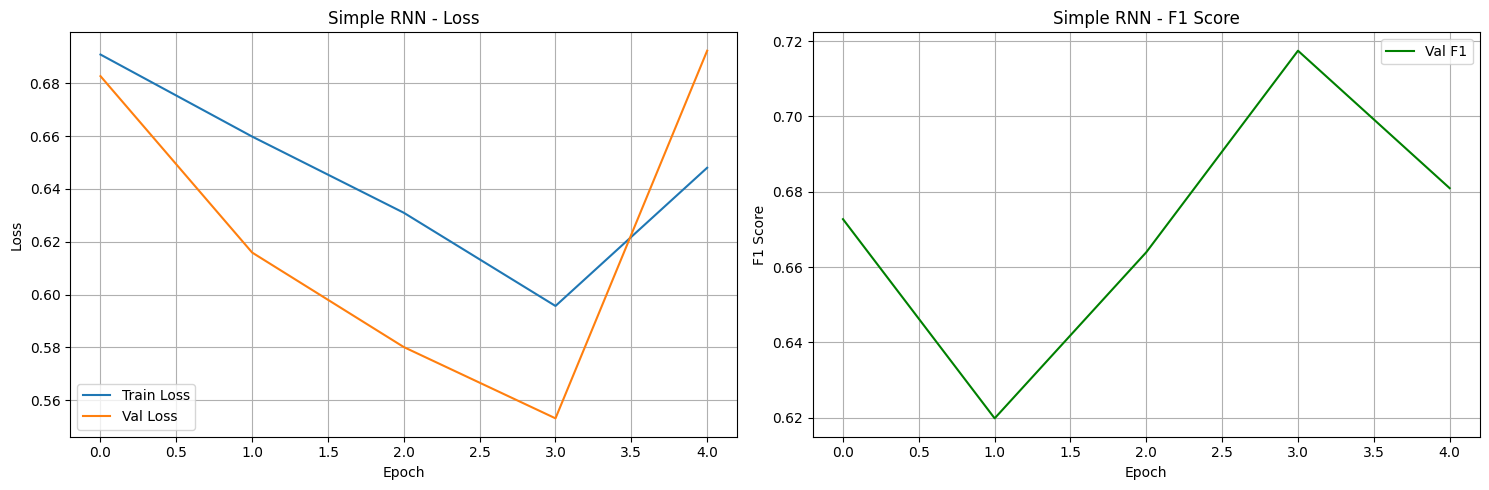


Графіки LSTM:


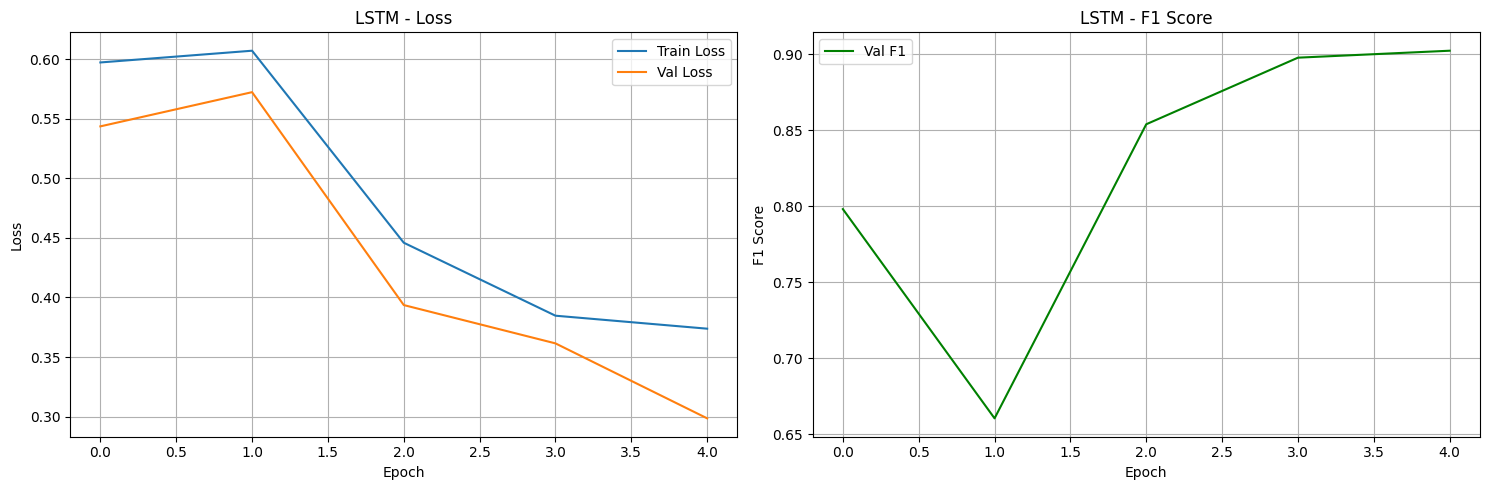


Confusion Matrix RNN:


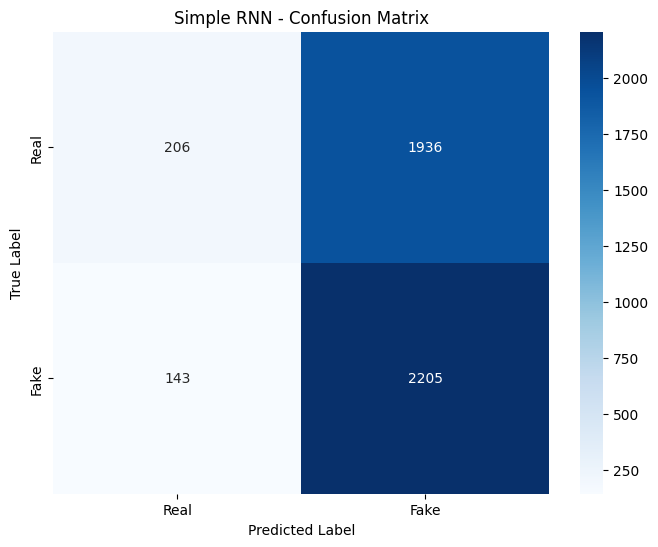


Confusion Matrix LSTM:


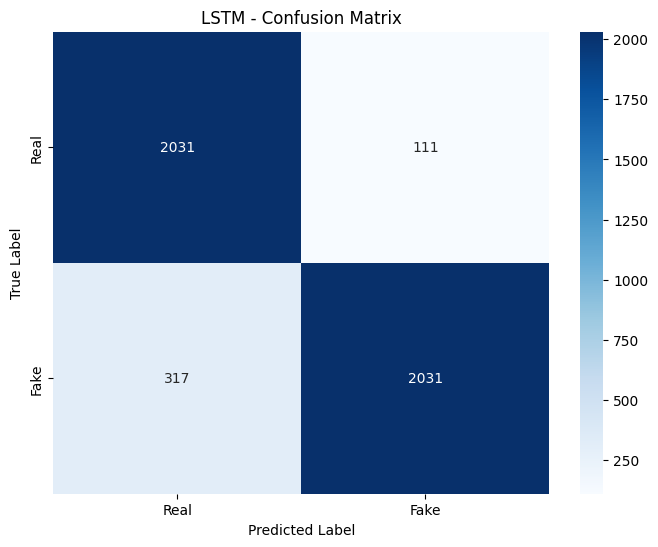


ROC Curve RNN:


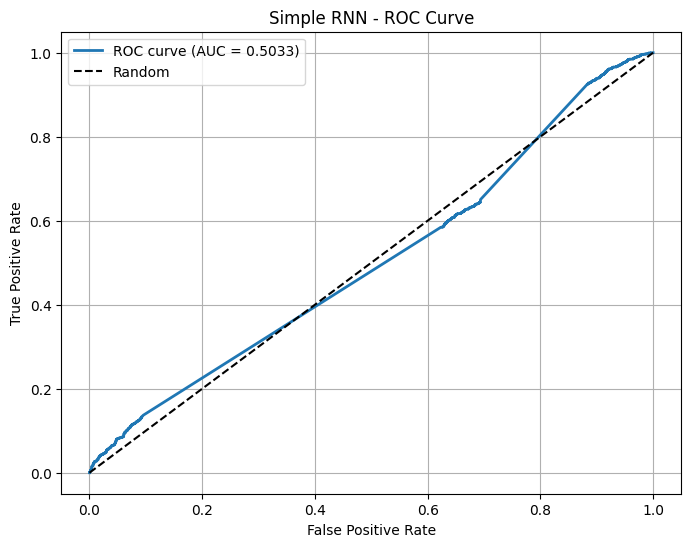


ROC Curve LSTM:


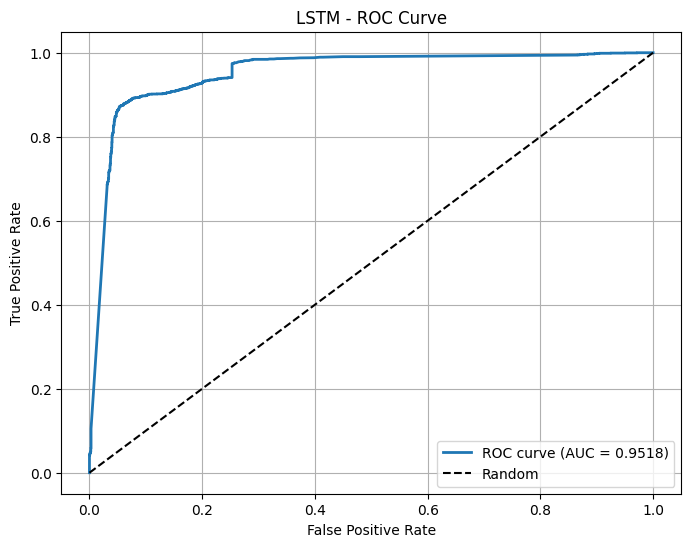


Порівняння ROC кривих:


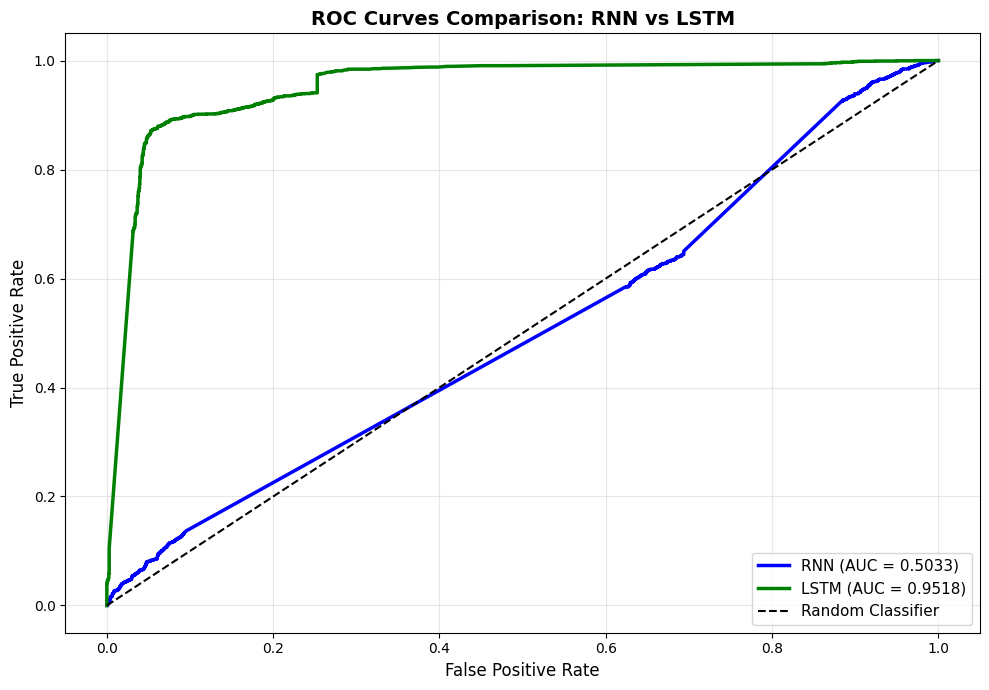

In [ ]:
# СЕКЦІЯ 13: Візуалізація результатів
# ===================================================================

print("\n" + "="*60)
print("ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ")
print("="*60)

# Графіки тренування RNN
print("\nГрафіки RNN:")
plot_training_history(rnn_history, "Simple RNN")

# Графіки тренування LSTM
print("\nГрафіки LSTM:")
plot_training_history(lstm_history, "LSTM")

# Confusion Matrix - RNN
print("\nConfusion Matrix RNN:")
plot_confusion_matrix(test_labels, rnn_preds, "Simple RNN")

# Confusion Matrix - LSTM
print("\nConfusion Matrix LSTM:")
plot_confusion_matrix(test_labels, lstm_preds, "LSTM")

# ROC Curve - RNN
print("\nROC Curve RNN:")
plot_roc_curve(test_labels, rnn_probs, "Simple RNN")

# ROC Curve - LSTM
print("\nROC Curve LSTM:")
plot_roc_curve(test_labels, lstm_probs, "LSTM")
# Порівняння ROC кривих на одному графіку
print("\nПорівняння ROC кривих:")
plt.figure(figsize=(10, 7))

fpr_rnn, tpr_rnn, _ = roc_curve(test_labels, rnn_probs)
fpr_lstm, tpr_lstm, _ = roc_curve(test_labels, lstm_probs)

plt.plot(fpr_rnn, tpr_rnn, label=f'RNN (AUC = {rnn_test_metrics["roc_auc"]:.4f})',
         linewidth=2.5, color='blue')
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {lstm_test_metrics["roc_auc"]:.4f})',
         linewidth=2.5, color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison: RNN vs LSTM', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

14. У цьому секторі створюється порівняльна таблиця та графіки ключових метрик, часу тренування та кількості параметрів для моделей RNN і LSTM, а також обчислюється різниця та покращення показників LSTM відносно RNN.


ПОРІВНЯЛЬНА ТАБЛИЦЯ

      Model  Accuracy  Precision   Recall  F1-Score  ROC AUC  Parameters  Training Time (s)
Simple RNN  0.536971   0.532480 0.939097  0.679612 0.503324     2029569        2563.897428
      LSTM  0.904677   0.948179 0.864991  0.904677 0.951820     2117889        7789.692705

 Порівняльну таблицю збережено в 'model_comparison.csv'


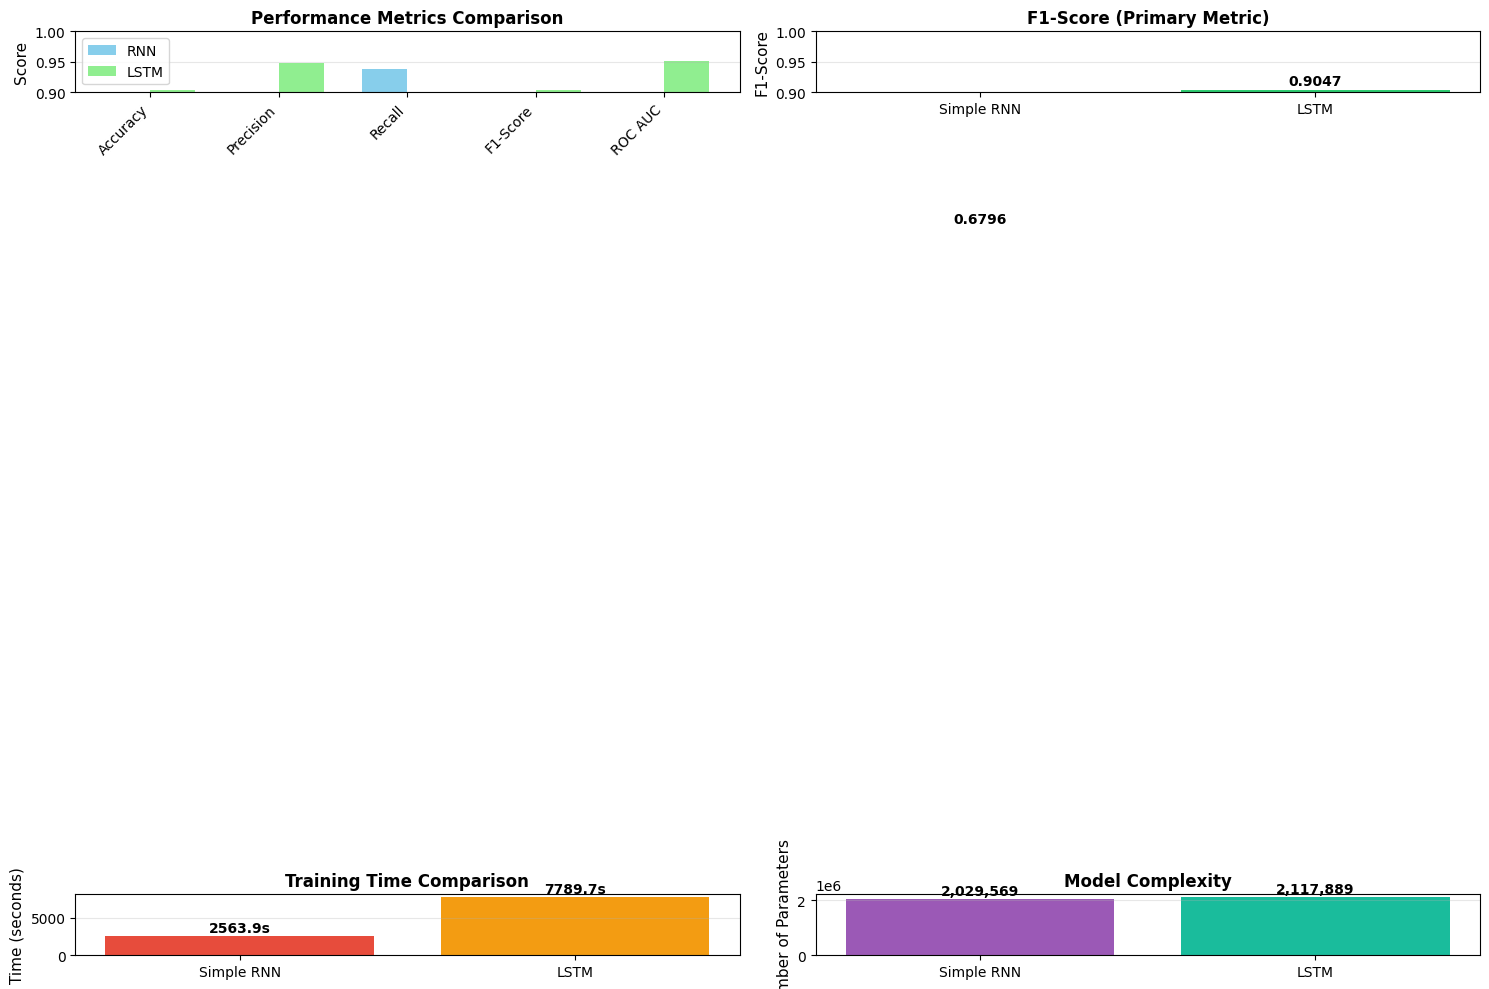


РІЗНИЦЯ МІЖ МОДЕЛЯМИ (LSTM - RNN)
   Metric  Difference  Improvement (%)
 Accuracy    0.367706        68.477810
Precision    0.415699        78.068497
   Recall   -0.074106        -7.891156
 F1-Score    0.225065        33.116767
  ROC AUC    0.448496        89.106961

  LSTM тренується повільніше на 203.8%
 LSTM має більше параметрів на 4.4%


In [ ]:
# СЕКЦІЯ 14: Порівняльна таблиця результатів
# ===================================================================

print("\n" + "="*60)
print("ПОРІВНЯЛЬНА ТАБЛИЦЯ")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM'],
    'Accuracy': [rnn_test_metrics['accuracy'], lstm_test_metrics['accuracy']],
    'Precision': [rnn_test_metrics['precision'], lstm_test_metrics['precision']],
    'Recall': [rnn_test_metrics['recall'], lstm_test_metrics['recall']],
    'F1-Score': [rnn_test_metrics['f1'], lstm_test_metrics['f1']],
    'ROC AUC': [rnn_test_metrics['roc_auc'], lstm_test_metrics['roc_auc']],
    'Parameters': [rnn_params, lstm_params],
    'Training Time (s)': [rnn_time, lstm_time]
})

print("\n", comparison_df.to_string(index=False))

# Збереження таблиці
comparison_df.to_csv('model_comparison.csv', index=False)
print("\n Порівняльну таблицю збережено в 'model_comparison.csv'")
# Візуальне порівняння метрик
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

models = comparison_df['Model']

# 1. Метрики якості
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
rnn_scores = [comparison_df.loc[0, m] for m in metrics]
lstm_scores = [comparison_df.loc[1, m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

axes[0, 0].bar(x - width/2, rnn_scores, width, label='RNN', color='skyblue')
axes[0, 0].bar(x + width/2, lstm_scores, width, label='LSTM', color='lightgreen')
axes[0, 0].set_ylabel('Score', fontsize=11)
axes[0, 0].set_title('Performance Metrics Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0.9, 1.0])  # Zoom на відмінності

# 2. F1-Score (головна метрика)
axes[0, 1].bar(models, comparison_df['F1-Score'], color=['#3498db', '#2ecc71'])
axes[0, 1].set_ylabel('F1-Score', fontsize=11)
axes[0, 1].set_title('F1-Score (Primary Metric)', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_ylim([0.9, 1.0])

# Додавання значень на стовпчиках
for i, v in enumerate(comparison_df['F1-Score']):
    axes[0, 1].text(i, v + 0.002, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# 3. Час тренування
axes[1, 0].bar(models, comparison_df['Training Time (s)'], color=['#e74c3c', '#f39c12'])
axes[1, 0].set_ylabel('Time (seconds)', fontsize=11)
axes[1, 0].set_title('Training Time Comparison', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df['Training Time (s)']):
    axes[1, 0].text(i, v + max(comparison_df['Training Time (s)'])*0.02,
                     f'{v:.1f}s', ha='center', va='bottom', fontweight='bold')

# 4. Кількість параметрів
axes[1, 1].bar(models, comparison_df['Parameters'], color=['#9b59b6', '#1abc9c'])
axes[1, 1].set_ylabel('Number of Parameters', fontsize=11)
axes[1, 1].set_title('Model Complexity', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df['Parameters']):
    axes[1, 1].text(i, v + max(comparison_df['Parameters'])*0.02,
                     f'{v:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Статистична таблиця різниць
print("\n" + "="*60)
print("РІЗНИЦЯ МІЖ МОДЕЛЯМИ (LSTM - RNN)")
print("="*60)

diff_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC'],
    'Difference': [
        lstm_test_metrics['accuracy'] - rnn_test_metrics['accuracy'],
        lstm_test_metrics['precision'] - rnn_test_metrics['precision'],
        lstm_test_metrics['recall'] - rnn_test_metrics['recall'],
        lstm_test_metrics['f1'] - rnn_test_metrics['f1'],
        lstm_test_metrics['roc_auc'] - rnn_test_metrics['roc_auc']
    ],
    'Improvement (%)': [
        (lstm_test_metrics['accuracy'] - rnn_test_metrics['accuracy']) / rnn_test_metrics['accuracy'] * 100,
        (lstm_test_metrics['precision'] - rnn_test_metrics['precision']) / rnn_test_metrics['precision'] * 100,
        (lstm_test_metrics['recall'] - rnn_test_metrics['recall']) / rnn_test_metrics['recall'] * 100,
        (lstm_test_metrics['f1'] - rnn_test_metrics['f1']) / rnn_test_metrics['f1'] * 100,
        (lstm_test_metrics['roc_auc'] - rnn_test_metrics['roc_auc']) / rnn_test_metrics['roc_auc'] * 100
    ]
})

print(diff_df.to_string(index=False))

# Швидкість тренування
time_ratio = lstm_time / rnn_time
print(f"\n  LSTM тренується {'повільніше' if time_ratio > 1 else 'швидше'} на {abs(time_ratio - 1)*100:.1f}%")

# Складність моделі
param_ratio = lstm_params / rnn_params
print(f" LSTM має {'більше' if param_ratio > 1 else 'менше'} параметрів на {abs(param_ratio - 1)*100:.1f}%")

15. У цій секції проводиться обмежений пошук гіперпараметрів для LSTM-моделі, включаючи embedding, hidden size, кількість шарів, bidirectional, learning rate, dropout та batch size. Для кожної конфігурації відбувається тренування, оцінка на тестовому наборі, збереження результатів у таблицю та їх візуалізація для порівняння продуктивності, складності та часу тренування.

In [1]:
# СЕКЦІЯ 15: Hyperparameter Search
# ===================================================================

print("\n" + "="*60)
print("HYPERPARAMETER SEARCH")
print("="*60)

# Обмежений набір для швидкого тестування
# (для повного дослідження збільште кількість конфігурацій)

hyperparameter_configs = [
    # Базова
    {'name': 'Baseline', 'emb_dim': 100, 'hidden_dim': 128, 'num_layers': 1,
     'lr': 0.001, 'dropout': 0.2, 'batch_size': 64, 'bidirectional': False},

    # Збільшений embedding
    {'name': 'Emb_200', 'emb_dim': 200, 'hidden_dim': 128, 'num_layers': 1,
     'lr': 0.001, 'dropout': 0.2, 'batch_size': 64, 'bidirectional': False},

    # Збільшений hidden
    {'name': 'Hidden_256', 'emb_dim': 100, 'hidden_dim': 256, 'num_layers': 1,
     'lr': 0.001, 'dropout': 0.2, 'batch_size': 64, 'bidirectional': False},

    # 2 layers
    {'name': '2_Layers', 'emb_dim': 100, 'hidden_dim': 128, 'num_layers': 2,
     'lr': 0.001, 'dropout': 0.2, 'batch_size': 64, 'bidirectional': False},

    # Bidirectional
    {'name': 'Bidirectional', 'emb_dim': 100, 'hidden_dim': 128, 'num_layers': 1,
     'lr': 0.001, 'dropout': 0.2, 'batch_size': 64, 'bidirectional': True},

    # Нижча learning rate
    {'name': 'LR_0.0005', 'emb_dim': 100, 'hidden_dim': 128, 'num_layers': 1,
     'lr': 0.0005, 'dropout': 0.2, 'batch_size': 64, 'bidirectional': False},

    # Вищий dropout
    {'name': 'Dropout_0.5', 'emb_dim': 100, 'hidden_dim': 128, 'num_layers': 1,
     'lr': 0.001, 'dropout': 0.5, 'batch_size': 64, 'bidirectional': False},

    # Менший batch
    {'name': 'Batch_32', 'emb_dim': 100, 'hidden_dim': 128, 'num_layers': 1,
     'lr': 0.001, 'dropout': 0.2, 'batch_size': 32, 'bidirectional': False},
]

hp_results = []

for idx, config in enumerate(hyperparameter_configs):
    print(f"\n{'='*60}")
    print(f"Експеримент {idx+1}/{len(hyperparameter_configs)}: {config['name']}")
    print(f"{'='*60}")
    print(f"Config: {config}")

    set_seed(42)

    # DataLoaders
    train_loader_hp = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader_hp = DataLoader(val_dataset, batch_size=config['batch_size'])
    test_loader_hp = DataLoader(test_dataset, batch_size=config['batch_size'])

    # Модель
    model_hp = LSTMClassifier(
        vocab_size=len(word2idx),
        emb_dim=config['emb_dim'],
        hidden_dim=config['hidden_dim'],
        num_layers=config['num_layers'],
        bidirectional=config['bidirectional'],
        dropout=config['dropout']
    ).to(device)

    n_params = sum(p.numel() for p in model_hp.parameters() if p.requires_grad)
    print(f"Параметрів: {n_params:,}")

    optimizer_hp = optim.Adam(model_hp.parameters(), lr=config['lr'])

    # Тренування
    model_hp, history_hp, time_hp = train_model(
        model_hp, train_loader_hp, val_loader_hp,
        criterion, optimizer_hp,
        num_epochs=BASE_CONFIG['num_epochs'],
        device=device,
        model_name=config['name']
    )

    # Тестування
    test_metrics_hp, _, _, _ = evaluate(model_hp, test_loader_hp, criterion, device)

    hp_results.append({
        'Name': config['name'],
        'Emb Dim': config['emb_dim'],
        'Hidden': config['hidden_dim'],
        'Layers': config['num_layers'],
        'Bidir': config['bidirectional'],
        'LR': config['lr'],
        'Dropout': config['dropout'],
        'Batch': config['batch_size'],
        'Val F1': max(history_hp['val_f1']),
        'Test F1': test_metrics_hp['f1'],
        'ROC AUC': test_metrics_hp['roc_auc'],
        'Time (s)': time_hp,
        'Params': n_params
    })

# Результати
print("\n" + "="*80)
print("РЕЗУЛЬТАТИ HYPERPARAMETER SEARCH")
print("="*80)

hp_df = pd.DataFrame(hp_results)
print("\n", hp_df.to_string(index=False))

# Збереження
hp_df.to_csv('hyperparameter_search_results.csv', index=False)

# Найкраща конфігурація
best_idx = hp_df['Test F1'].idxmax()
print(f"\n{'='*60}")
print(" НАЙКРАЩА КОНФІГУРАЦІЯ")
print(f"{'='*60}")
print(hp_df.iloc[best_idx].to_string())

# Візуалізація
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# F1 Score
axes[0, 0].barh(hp_df['Name'], hp_df['Test F1'], color='green', alpha=0.7)
axes[0, 0].set_xlabel('F1 Score')
axes[0, 0].set_title('F1 Score по конфігураціях')
axes[0, 0].axvline(hp_df['Test F1'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)

# ROC AUC
axes[0, 1].barh(hp_df['Name'], hp_df['ROC AUC'], color='blue', alpha=0.7)
axes[0, 1].set_xlabel('ROC AUC')
axes[0, 1].set_title('ROC AUC по конфігураціях')
axes[0, 1].grid(axis='x', alpha=0.3)

# Training Time
axes[1, 0].barh(hp_df['Name'], hp_df['Time (s)'], color='orange', alpha=0.7)
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].set_title('Training Time по конфігураціях')
axes[1, 0].grid(axis='x', alpha=0.3)

# Parameters
axes[1, 1].barh(hp_df['Name'], hp_df['Params'], color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Number of Parameters')
axes[1, 1].set_title('Model Size по конфігураціях')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Результати hyperparameter search збережено!")